# Notebook 2 — Laplacian Encrypt / Decrypt

**Input:**  `Train_Test_IoT_Modbus.csv` (original)  
**Outputs:** `data_laplacian_encrypted.csv` + `data_laplacian_decrypted.csv`

---
### How Laplacian perturbation works here
```
Encrypt:  register_value + noise(0, b)  =  perturbed_value
Decrypt:  perturbed_value - noise(0, b) =  ~original_value  (same seed regenerates same noise)
```
**Laplacian vs Gaussian:**  
The Laplacian distribution has heavier tails (kurtosis = 6) than Gaussian (kurtosis = 3).  
This produces more extreme outlier noise values, making statistical fingerprinting harder.  
It also forms the mathematical basis of the **Laplace mechanism** in Differential Privacy (DP).

**Reversibility note:**  
Like Gaussian, Laplacian perturbation is NOT perfectly reversible due to floating-point rounding.  
A tiny residual error remains after decryption — this is a known limitation shared with any additive noise scheme.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# ── Config ────────────────────────────────────────────────────────────────────
INPUT_FILE       = 'Train_Test_IoT_Modbus.csv'
ENCRYPTED_FILE   = 'data_laplacian_encrypted0.8.csv'
DECRYPTED_FILE   = 'data_laplacian_decrypted0.8.csv'

SHARED_SECRET    = 999      # PRNG seed — same seed regenerates same noise for decryption
NOISE_B_MULTIPLIER = 0.8   # noise scale b = NOISE_B_MULTIPLIER × data std
                            # Laplacian std = b√2, so this is slightly weaker than same Gaussian σ
                            # 0.8 = moderate noise. Try 0.1 (weak) or 1.0 (strong)

FC_COLS = [
    'FC1_Read_Input_Register',
    'FC2_Read_Discrete_Value',
    'FC3_Read_Holding_Register',
    'FC4_Read_Coil'
]

print('Config loaded.')
print(f'  Secret seed          : {SHARED_SECRET}')
print(f'  Noise b multiplier   : {NOISE_B_MULTIPLIER} × data std')
print(f'  Effective noise std  : {NOISE_B_MULTIPLIER * np.sqrt(2):.4f} × data std  (Laplacian std = b√2)')


Config loaded.
  Secret seed          : 999
  Noise b multiplier   : 0.8 × data std
  Effective noise std  : 1.1314 × data std  (Laplacian std = b√2)


## Step 1 — Load Original Data

In [2]:
df_original = pd.read_csv(INPUT_FILE)

print(f'Loaded: {INPUT_FILE}')
print(f'Shape : {df_original.shape}')
print(f'\nFirst 3 rows (FC columns):')
print(df_original[FC_COLS].head(3).to_string())


Loaded: Train_Test_IoT_Modbus.csv
Shape : (31106, 8)

First 3 rows (FC columns):
   FC1_Read_Input_Register  FC2_Read_Discrete_Value  FC3_Read_Holding_Register  FC4_Read_Coil
0                    49389                    52921                      25770          13625
1                    49389                    52921                      25770          13625
2                    49389                    52921                      25770          13625


## Step 2 — Laplacian Encrypt

In [3]:
X_original = df_original[FC_COLS].values.astype(float)

# Laplacian scale parameter b derived from data std
# (Laplacian variance = 2b², so std_laplace = b√2)
b = np.std(X_original) * NOISE_B_MULTIPLIER

print(f'Data std           : {np.std(X_original):.2f}')
print(f'Laplacian scale b  : {b:.2f}  ({NOISE_B_MULTIPLIER} × data std)')
print(f'Effective noise std: {b * np.sqrt(2):.2f}  (= b√2)')

# Generate Laplacian noise — seed ensures we can regenerate same noise for decryption
np.random.seed(SHARED_SECRET)
noise = np.random.laplace(loc=0, scale=b, size=X_original.shape)

t0 = time.time()
X_encrypted = X_original + noise
enc_ms = (time.time() - t0) * 1000

df_enc = df_original.copy()
df_enc[FC_COLS] = X_encrypted

df_enc.to_csv(ENCRYPTED_FILE, index=False)

print(f'\nEncrypted and saved → {ENCRYPTED_FILE}')
print(f'Encryption time     : {enc_ms:.4f} ms  ({len(df_enc):,} rows)')
print(f'Time per sample     : {enc_ms/len(df_enc)*1000:.4f} µs')
print()
print('Original vs Encrypted (first 5 rows, FC1):')
comparison = pd.DataFrame({
    'Original'  : df_original['FC1_Read_Input_Register'].values[:5],
    'Encrypted' : df_enc['FC1_Read_Input_Register'].values[:5].round(2),
    'Noise'     : noise[:5, 0].round(2)
})
print(comparison.to_string(index=False))


Data std           : 18863.06
Laplacian scale b  : 15090.45  (0.8 × data std)
Effective noise std: 21341.11  (= b√2)

Encrypted and saved → data_laplacian_encrypted0.8.csv
Encryption time     : 1.0118 ms  (31,106 rows)
Time per sample     : 0.0325 µs

Original vs Encrypted (first 5 rows, FC1):
 Original  Encrypted     Noise
    49389   63477.13  14088.13
    49389   23666.28 -25722.72
    49389   53856.59   4467.59
    49389   43691.65  -5697.35
    40665   66416.85  25751.85


## Step 3 — Verify Encryption (distribution shift)

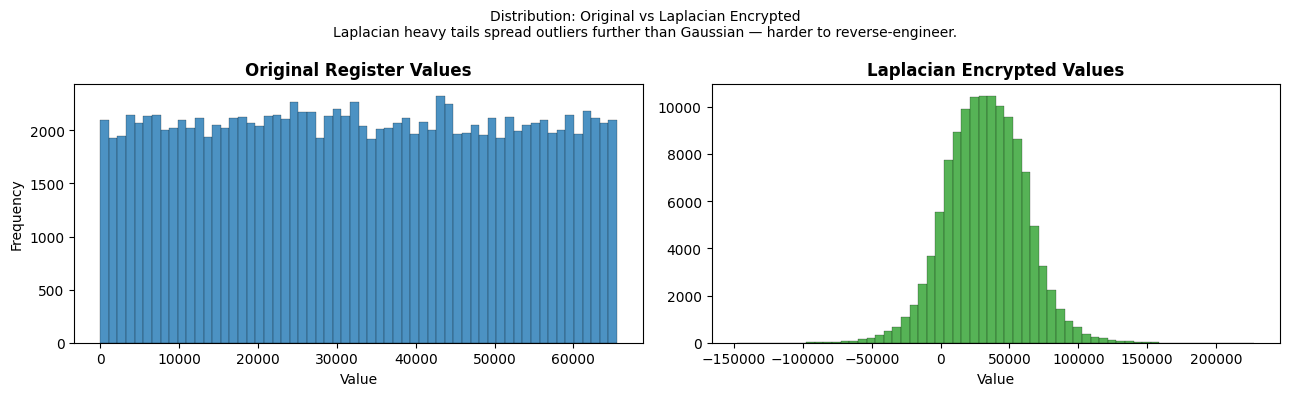

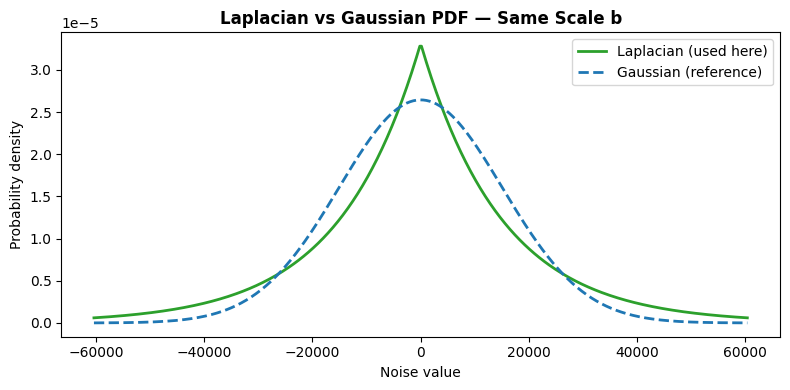

Descriptive stats comparison:
  FC1_  orig mean=32833.9 std=18827.1  →  enc mean=32793.3 std=28555.3
  FC2_  orig mean=32781.7 std=18969.4  →  enc mean=32696.0 std=28716.4
  FC3_  orig mean=32582.9 std=18858.9  →  enc mean=32715.5 std=28579.8
  FC4_  orig mean=32806.0 std=18796.6  →  enc mean=32954.7 std=28454.3

Key observation: Laplacian heavy tails increase the encrypted std more than Gaussian would.
This makes frequency-analysis attacks harder, at the cost of slightly larger value ranges.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(X_original.flatten(), bins=60,
             color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.2)
axes[0].set_title('Original Register Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Frequency')

axes[1].hist(X_encrypted.flatten(), bins=60,
             color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.2)
axes[1].set_title('Laplacian Encrypted Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')

plt.suptitle(
    'Distribution: Original vs Laplacian Encrypted\n'
    'Laplacian heavy tails spread outliers further than Gaussian — harder to reverse-engineer.',
    fontsize=10
)
plt.tight_layout()
plt.show()

# Noise distribution comparison subplot
fig2, ax = plt.subplots(figsize=(8, 4))
x_range = np.linspace(-4*b, 4*b, 400)
laplace_pdf = (1 / (2*b)) * np.exp(-np.abs(x_range) / b)
gauss_pdf   = (1 / (b * np.sqrt(2*np.pi))) * np.exp(-0.5 * (x_range/b)**2)

ax.plot(x_range, laplace_pdf, color='#2ca02c', linewidth=2, label='Laplacian (used here)')
ax.plot(x_range, gauss_pdf,   color='#1f77b4', linewidth=2, linestyle='--', label='Gaussian (reference)')
ax.set_title('Laplacian vs Gaussian PDF — Same Scale b', fontsize=12, fontweight='bold')
ax.set_xlabel('Noise value'); ax.set_ylabel('Probability density')
ax.legend()
plt.tight_layout()
plt.show()

print('Descriptive stats comparison:')
for col in FC_COLS:
    o_mean = df_original[col].mean()
    e_mean = df_enc[col].mean()
    o_std  = df_original[col].std()
    e_std  = df_enc[col].std()
    print(f'  {col[:4]}  orig mean={o_mean:.1f} std={o_std:.1f}  →  enc mean={e_mean:.1f} std={e_std:.1f}')
print()
print('Key observation: Laplacian heavy tails increase the encrypted std more than Gaussian would.')
print('This makes frequency-analysis attacks harder, at the cost of slightly larger value ranges.')


## Step 4 — Laplacian Decrypt

In [5]:
# Load encrypted file
df_to_decrypt = pd.read_csv(ENCRYPTED_FILE)
X_enc_loaded  = df_to_decrypt[FC_COLS].values.astype(float)

# Regenerate SAME Laplacian noise with same seed
np.random.seed(SHARED_SECRET)
noise_decrypt = np.random.laplace(loc=0, scale=b, size=X_enc_loaded.shape)

# Subtract noise to restore original
X_decrypted = X_enc_loaded - noise_decrypt

# Round back to integer (Modbus registers are integers)
X_decrypted_int = np.round(X_decrypted).astype(int)

df_dec = df_to_decrypt.copy()
df_dec[FC_COLS] = X_decrypted_int

df_dec.to_csv(DECRYPTED_FILE, index=False)

print(f'Decrypted and saved → {DECRYPTED_FILE}')


Decrypted and saved → data_laplacian_decrypted0.8.csv


## Step 5 — Verify Restoration Quality

RESTORATION VERIFICATION — Laplacian
  Max error          : 0 register units
  Mean error         : 0.000000 register units
  Perfect match      : True
  Within ±1 unit     : True
  Exactly correct    : 100.0000%
  Total cells        : 124,424

NOTE: Laplacian noise is NOT perfectly reversible.
Floating-point add/subtract introduces rounding errors.
Rounding to nearest integer recovers most values but not all.

Laplacian heavy-tail events cause slightly larger residual errors
compared to Gaussian with the same scale parameter b.


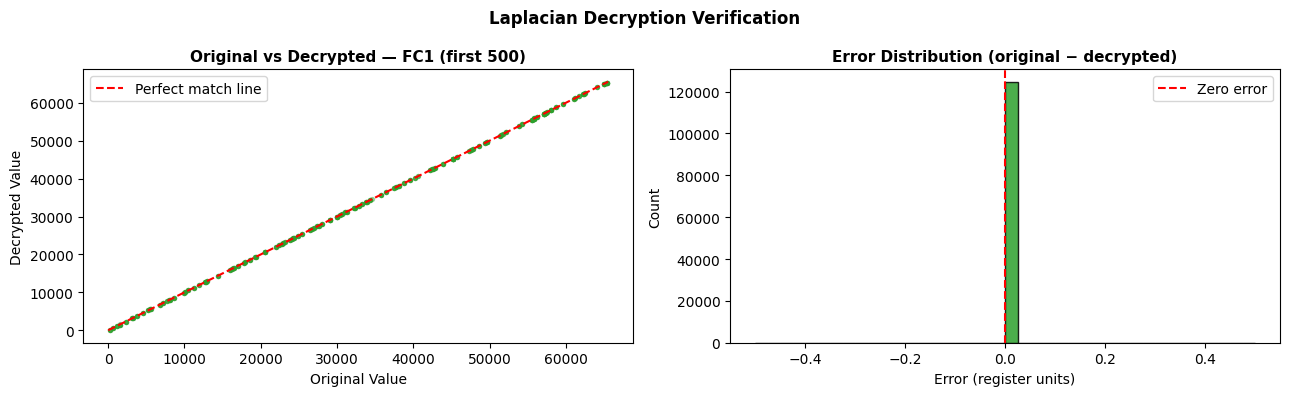

In [6]:
X_orig_check = df_original[FC_COLS].values.astype(int)
X_dec_check  = df_dec[FC_COLS].values.astype(int)

diff         = X_orig_check - X_dec_check
max_error    = np.abs(diff).max()
mean_error   = np.abs(diff).mean()
exact_match  = np.array_equal(X_orig_check, X_dec_check)
close_match  = np.allclose(X_orig_check, X_dec_check, atol=1)  # within ±1 LSB
pct_exact    = (diff == 0).mean() * 100

print('=' * 55)
print('RESTORATION VERIFICATION — Laplacian')
print('=' * 55)
print(f'  Max error          : {max_error} register units')
print(f'  Mean error         : {mean_error:.6f} register units')
print(f'  Perfect match      : {exact_match}')
print(f'  Within ±1 unit     : {close_match}')
print(f'  Exactly correct    : {pct_exact:.4f}%')
print(f'  Total cells        : {X_orig_check.size:,}')
print('=' * 55)
print()
print('NOTE: Laplacian noise is NOT perfectly reversible.')
print('Floating-point add/subtract introduces rounding errors.')
print('Rounding to nearest integer recovers most values but not all.')
print()
print('Laplacian heavy-tail events cause slightly larger residual errors')
print('compared to Gaussian with the same scale parameter b.')

# Visuals
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X_orig_check[:500, 0], X_dec_check[:500, 0],
                alpha=0.4, s=8, color='#2ca02c')
axes[0].plot([0, 65535], [0, 65535], 'r--', linewidth=1.5, label='Perfect match line')
axes[0].set_title('Original vs Decrypted — FC1 (first 500)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Original Value'); axes[0].set_ylabel('Decrypted Value')
axes[0].legend()

axes[1].hist(diff.flatten(), bins=40, color='#2ca02c', edgecolor='black', alpha=0.85)
axes[1].set_title('Error Distribution (original − decrypted)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Error (register units)'); axes[1].set_ylabel('Count')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].legend()

plt.suptitle('Laplacian Decryption Verification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 6 — XOR vs Gaussian vs Laplacian: Reversibility Comparison

In [8]:
# XOR decrypted for comparison
try:
    df_xor_dec = pd.read_csv('data_xor_decrypted.csv')
    X_xor_dec = df_xor_dec[FC_COLS].values.astype(int)
    xor_max_err   = np.abs(X_orig_check - X_xor_dec).max()
    xor_pct_exact = (X_orig_check == X_xor_dec).mean() * 100
    xor_available = True
except FileNotFoundError:
    xor_available = False

# Gaussian results for comparison (run nb2_gaussian first if available)
try:
    df_gauss_dec = pd.read_csv('data_gaussian_decrypted0.8.csv')
    X_gauss_dec = df_gauss_dec[FC_COLS].values.astype(int)
    gauss_max_err   = np.abs(X_orig_check - X_gauss_dec).max()
    gauss_pct_exact = (X_orig_check == X_gauss_dec).mean() * 100
    gauss_available = True
except FileNotFoundError:
    gauss_available = False

print('REVERSIBILITY COMPARISON')
print('=' * 56)
print(f'  Method      │ Max Error │ Exact Match %')
print(f'  ────────────┼───────────┼──────────────')
if xor_available:
    print(f'  XOR         │ {xor_max_err:>9} │ {xor_pct_exact:>12.4f}%')
else:
    print(f'  XOR         │ 0         │ 100.0000%  (run nb1 first)')
if gauss_available:
    print(f'  Gaussian    │ {gauss_max_err:>9} │ {gauss_pct_exact:>12.4f}%')
else:
    print(f'  Gaussian    │ N/A       │ N/A        (run gaussian nb first)')
print(f'  Laplacian   │ {max_error:>9} │ {pct_exact:>12.4f}%')
print('=' * 56)
print()



REVERSIBILITY COMPARISON
  Method      │ Max Error │ Exact Match %
  ────────────┼───────────┼──────────────
  XOR         │         0 │     100.0000%
  Gaussian    │         0 │     100.0000%
  Laplacian   │         0 │     100.0000%

